# Планирование остановов станков на обслуживание

**Постановка.** На производственной линии работают N станков. Каждый станок работает циклами из трёх этапов. Каждый этап заканчивается плановым остановом на обслуживание:

| Этап | Вид обслуживания | Длительность останова |
|---|---|---|
| 1 | ТО-1 | 1 сут |
| 2 | ТО-2 | 2 сут |
| 3 | ТР (текущий ремонт) | 4 сут |

Перед каждым остановом станок должен отработать плановую наработку (около 30 сут). Наработку можно сократить или увеличить в пределах допуска (±15 %).

Требования к расписанию:
1. Фактическая наработка должна быть как можно ближе к плановой.
2. **Соседние станки не должны стоять на обслуживании одновременно:** иначе линия теряет два соседних участка сразу.
3. Число одновременных остановов не должно превышать число ремонтных бригад R. Загрузка бригад должна быть равномерной.

Задача решается пятью методами: MILP, CP-SAT, жадная эвристика H1, локальный поиск H2 и генетический алгоритм.

In [1]:
# !pip install -r requirements.txt
import pandas as pd
from IPython.display import Image, display

from msched import Instance, generate, evaluate, solve
from msched.plots import plan_starts, schedule_figure
from msched.report import schedule_table, export_excel

pd.set_option("display.max_rows", 20)

## Пример задачи

Генератор создаёт пример: 10 станков в линию (соседи — станки i и i+1), горизонт планирования 180 сут, 3 бригады. Половина станков начинает с одинакового состояния, поэтому их плановые остановы часто совпадают.

In [2]:
inst = generate(n_machines=10, horizon=180, seed=1, name="M_s1")
print(f"Станков: {inst.n_machines}, остановов: {inst.n}, бригад R = {inst.capacity}")
print(f"Пар соседних станков: {len(inst.neighbors)}, пар остановов, которые могут пересечься: {len(inst.pa)}")
schedule_table(inst, plan_starts(inst)).head(10)

Станков: 10, остановов: 59, бригад R = 3
Пар соседних станков: 9, пар остановов, которые могут пересечься: 96


,Станок,№ останова,Вид,Плановая наработка,Допустимо от,Допустимо до,Фактическая наработка,Отклонение,"Начало, сут","Конец, сут",Конфликт с соседом
0,1,1,ТО-2,18,14,22,18,0,18,20,
1,1,2,ТР,26,22,30,26,0,46,50,
2,1,3,ТО-1,26,22,30,26,0,76,77,да
3,1,4,ТО-2,26,22,30,26,0,103,105,
4,1,5,ТР,26,22,30,26,0,131,135,
5,1,6,ТО-1,26,22,30,26,0,161,162,
6,2,1,ТО-1,13,9,17,13,0,13,14,да
7,2,2,ТО-2,29,25,33,29,0,43,45,
8,2,3,ТР,29,25,33,29,0,74,78,да
9,2,4,ТО-1,29,25,33,29,0,107,108,


## Математическая модель

Обозначения: $a$ — останов, $r_a$ — плановая наработка, $d_a$ — длительность, $[lo_a, hi_a]$ — допустимая наработка, $p(a)$ — предыдущий останов того же станка, $E$ — пары остановов соседних станков, $R$ — число бригад.

Переменные: $s_a$ — момент начала останова; $z_{ab} \in \{0,1\}$ — остановы $a$ и $b$ пересекаются; $P$ — пиковое число одновременных остановов.

Фактическая наработка: $L_a = s_a - (s_{p(a)} + d_{p(a)})$, для первого останова станка $L_a = s_a$.

$$\min F = w_{dev} \sum_a |L_a - r_a| + w_{conf} \sum_{(a,b) \in E} z_{ab} + w_{peak} P$$

при ограничениях:

$$lo_a \le L_a \le hi_a, \qquad \#\{a : s_a \le t < s_a + d_a\} \le P \le R \quad \forall t,$$

$$z_{ab} = 0 \;\Rightarrow\; s_a + d_a + \delta \le s_b \;\lor\; s_b + d_b + \delta \le s_a.$$

Веса по умолчанию: $w_{dev} = 1$, $w_{conf} = 20$, $w_{peak} = 10$.

In [3]:
weights = inst.weights
print("Веса ЦФ:", weights)
plan = plan_starts(inst)
evaluate(inst, plan)

Веса ЦФ: {'dev': 1, 'conf': 20, 'peak': 10, 'over': 1000}


Metrics(objective=3400.0, sum_dev=0, max_dev=0, conflicts=18, peak=4, load_std=0.9637311316923491, overload=3, feasible=False)

Плановое расписание (все остановы точно по плановой наработке) нарушает требования: много конфликтов соседей, а пик загрузки превышает число бригад. Задача — сдвинуть остановы в пределах допуска.

## 1. Модель MILP (PuLP)

Индексация по времени: бинарная переменная $x_{a,t} = 1$, если останов $a$ начинается в момент $t$. Модель строится в PuLP (`msched/milp.py`) и решается решателем HiGHS.

In [4]:
res_milp = solve(inst, "milp", time_limit=30)
print(res_milp.status, res_milp.info)
evaluate(inst, res_milp.starts)

feasible {'nodes': 1, 'solver': 'highs', 'vars': 1884, 'constraints': 2443}


Metrics(objective=65.0, sum_dev=45, max_dev=4, conflicts=0, peak=2, load_std=0.7107266520934555, overload=0, feasible=True)

## 2. Модель CP-SAT (OR-Tools)

Те же переменные $s_a$, но пересечения записаны логическими условиями (`only_enforce_if`), а загрузка бригад — глобальным ограничением `add_cumulative` (`msched/cpsat.py`).

In [5]:
res_cpsat = solve(inst, "cpsat", time_limit=30)
print(res_cpsat.status, "нижняя оценка:", res_cpsat.bound)
evaluate(inst, res_cpsat.starts)

optimal нижняя оценка: 40.0


Metrics(objective=40.0, sum_dev=20, max_dev=4, conflicts=0, peak=2, load_std=0.7107266520934555, overload=0, feasible=True)

## 3. Эвристика H1 (жадная)

Остановы рассматриваются в порядке плановых моментов. Каждый останов ставится в момент из допустимого окна с минимальным приростом ЦФ относительно уже поставленных остановов.

In [6]:
res_h1 = solve(inst, "h1")
evaluate(inst, res_h1.starts)

Metrics(objective=83.0, sum_dev=43, max_dev=5, conflicts=1, peak=2, load_std=0.7445760254935785, overload=0, feasible=True)

## 4. Эвристика H2 (итерированный локальный поиск)

H2 улучшает расписание H1. Ходы: сдвиг одного останова (`shift`) или сдвиг останова вместе со всеми следующими (`push`). В локальном минимуме расписание случайно возмущается, и спуск повторяется.

In [7]:
res_h1h2 = solve(inst, "h1h2", time_limit=10)
evaluate(inst, res_h1h2.starts)

Metrics(objective=46.0, sum_dev=26, max_dev=4, conflicts=0, peak=2, load_std=0.7244562150285611, overload=0, feasible=True)

## 5. Генетический алгоритм

Хромосома — вектор наработок $L_a$. Кроссовер берёт гены станка целиком от одного из родителей, мутация сдвигает наработку на 1–3 сут.

In [8]:
res_ga = solve(inst, "ga", time_limit=10)
print("Поколений:", res_ga.info["generations"])
evaluate(inst, res_ga.starts)

Поколений: 717


Metrics(objective=60.0, sum_dev=40, max_dev=4, conflicts=0, peak=2, load_std=0.6896199850277444, overload=0, feasible=True)

## 6. Сравнение методов на этом примере

In [9]:
results = {"MILP": res_milp, "CP-SAT": res_cpsat, "H1": res_h1, "H1+H2": res_h1h2, "ГА": res_ga}
rows = []
for name, r in results.items():
    m = evaluate(inst, r.starts)
    rows.append({"Метод": name, "Статус": r.status, "ЦФ": m.objective, "Σ откл.": m.sum_dev,
                 "Конфликты": m.conflicts, "Пик": m.peak, "СКО загрузки": round(m.load_std, 3),
                 "До 1-го, с": round(r.t_first, 3), "До лучшего, с": round(r.t_best, 3),
                 "Всего, с": round(r.time_total, 2)})
pd.DataFrame(rows).set_index("Метод")

,Статус,ЦФ,Σ откл.,Конфликты,Пик,СКО загрузки,"До 1-го, с","До лучшего, с","Всего, с"
Метод,,,,,,,,,
MILP,feasible,65.0,45,0,2,0.711,0.533,30.231,30.27
CP-SAT,optimal,40.0,20,0,2,0.711,0.064,4.615,4.65
H1,heuristic,83.0,43,1,2,0.745,0.010,0.010,0.01
H1+H2,heuristic,46.0,26,0,2,0.724,0.010,7.474,10.00
ГА,heuristic,60.0,40,0,2,0.690,0.006,4.113,7.20


### Диаграмма Ганта: план и лучшее расписание

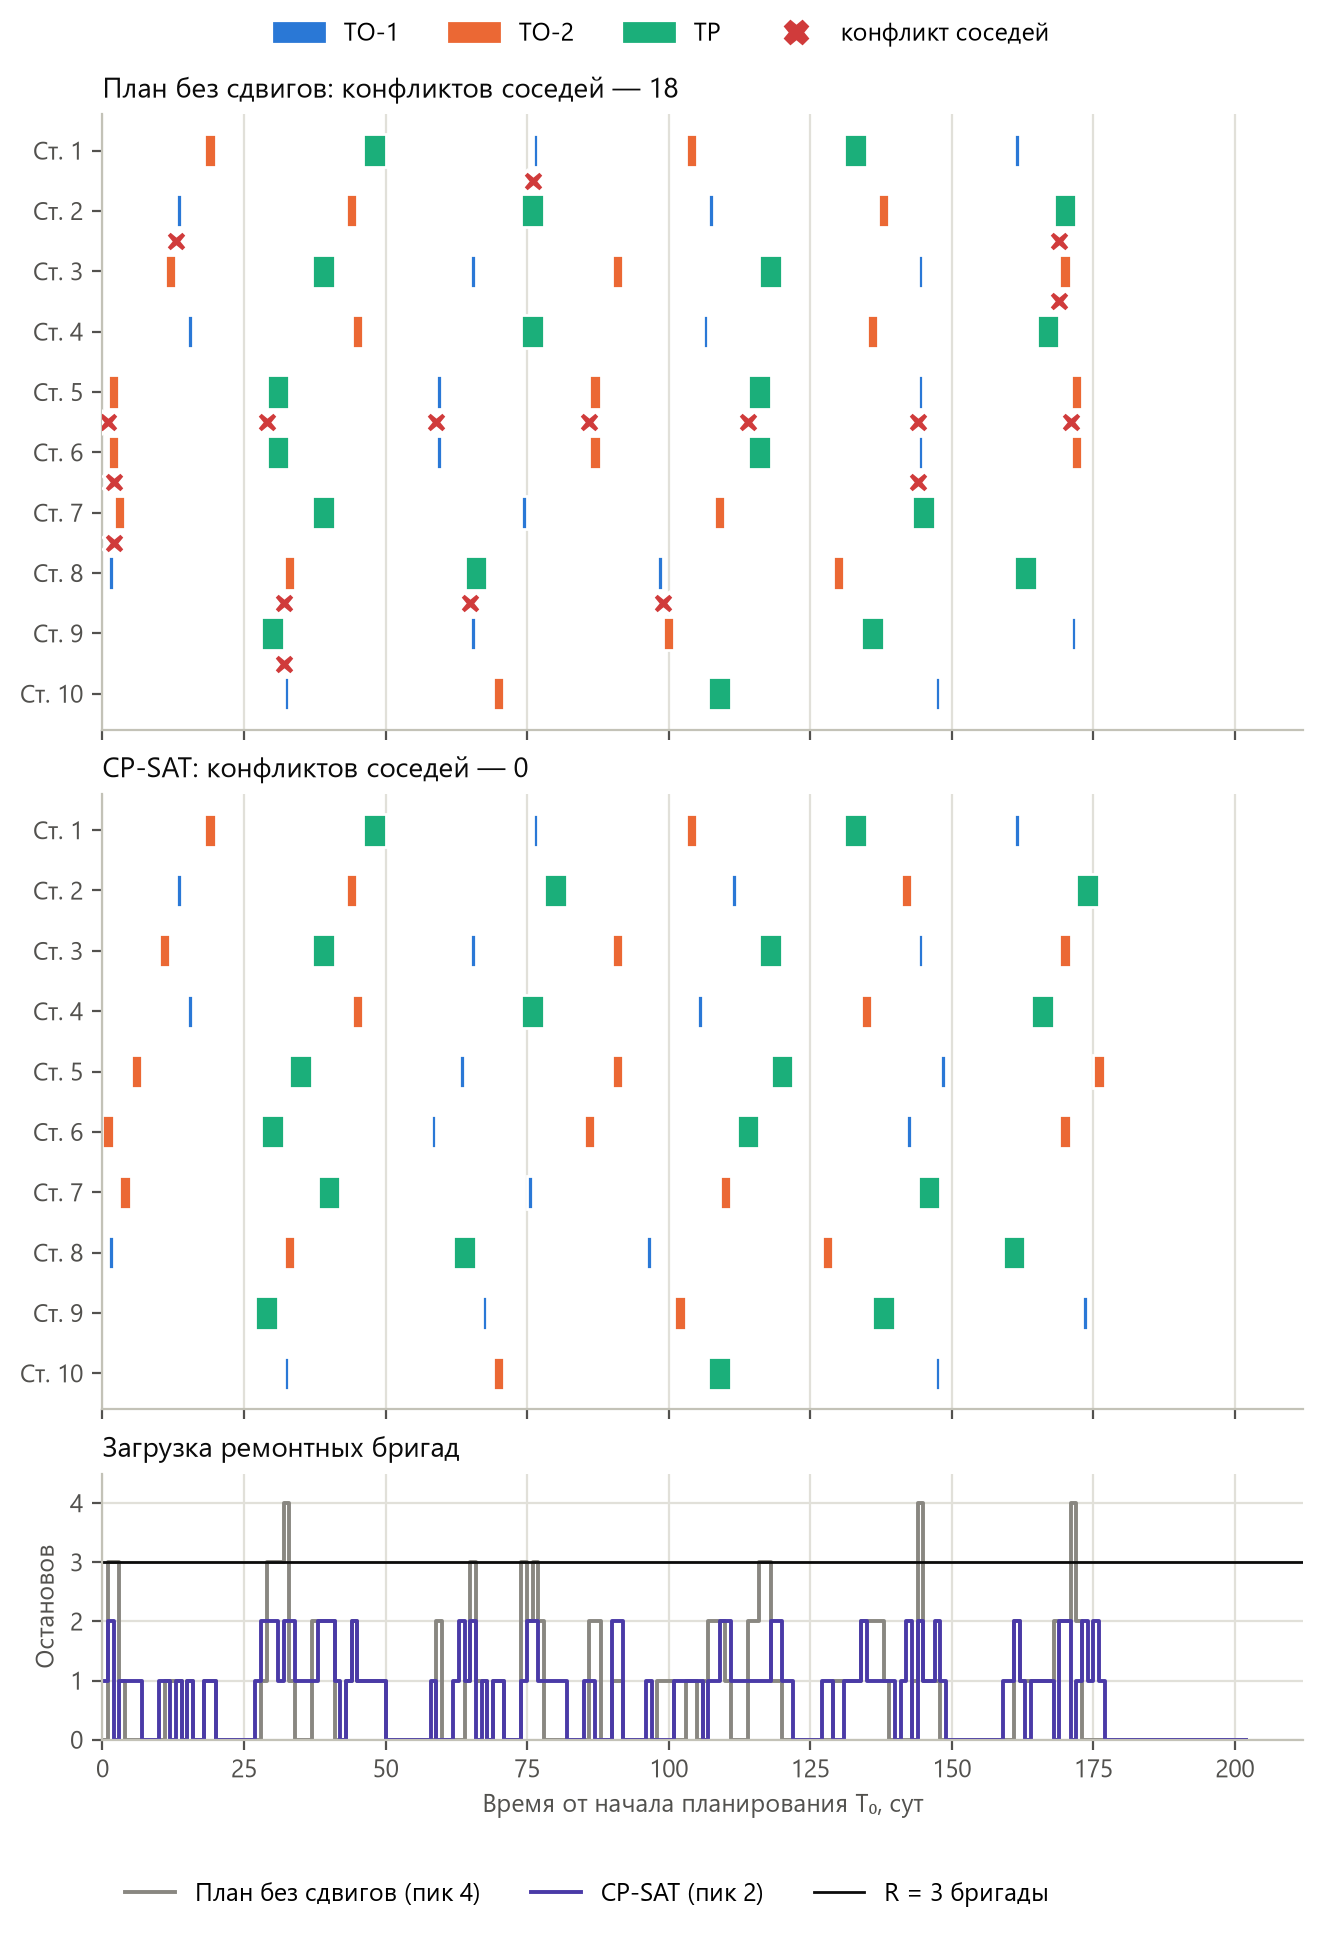

In [10]:
schedule_figure(inst, {"План без сдвигов": plan, "CP-SAT": res_cpsat.starts}, "figures/demo_gantt.png")
display(Image("figures/demo_gantt.png"))

### Выгрузка расписания в Excel

In [11]:
export_excel(inst, res_cpsat.starts, "results/schedule_M_s1.xlsx", method="CP-SAT")
schedule_table(inst, res_cpsat.starts).head(10)

,Станок,№ останова,Вид,Плановая наработка,Допустимо от,Допустимо до,Фактическая наработка,Отклонение,"Начало, сут","Конец, сут",Конфликт с соседом
0,1,1,ТО-2,18,14,22,18,0,18,20,
1,1,2,ТР,26,22,30,26,0,46,50,
2,1,3,ТО-1,26,22,30,26,0,76,77,
3,1,4,ТО-2,26,22,30,26,0,103,105,
4,1,5,ТР,26,22,30,26,0,131,135,
5,1,6,ТО-1,26,22,30,26,0,161,162,
6,2,1,ТО-1,13,9,17,13,0,13,14,
7,2,2,ТО-2,29,25,33,29,0,43,45,
8,2,3,ТР,29,25,33,33,4,78,82,
9,2,4,ТО-1,29,25,33,29,0,111,112,


## 7. Результаты вычислительных экспериментов

Полный прогон запускается из командной строки (около 70 мин):

```
bash scripts/run_experiments.sh
python -m msched plots
```

Ниже — средние значения по примерам размеров S (5 станков), M (10 станков) и L (20 станков), лимит времени 60 с на метод.

In [12]:
summary = pd.read_csv("results/bench_summary.csv", index_col=[0, 1])
summary

objective  gap_best_pct  sum_dev  conflicts   peak  load_std  \
size method                                                                 
L    cpsat     118.667         0.000   78.667      0.000  4.000     1.156   
     ga        285.333       140.805  218.667      1.333  4.000     1.123   
     h1        205.000        72.509  135.000      1.667  3.667     1.110   
     h1h2      148.333        25.394  108.333      0.000  4.000     1.141   
     milp     1575.000      1400.000  905.000     31.000  5.000     1.325   
M    cpsat      37.000         0.000   17.000      0.000  2.000     0.747   
     ga         53.000        42.153   29.667      0.000  2.333     0.743   
     h1         61.000        63.798   27.667      0.333  2.667     0.742   
     h1h2       40.667         9.626   20.667      0.000  2.000     0.697   
     milp       50.000        32.986   30.000      0.000  2.000     0.702   
S    cpsat      20.000         0.000   10.000      0.000  1.000     0.468   
     ga         22.000         9.825   12.000      0.000  1.000     0.468   
     h1         22.667        13.602    9.333      0.000  1.333     0.490   
     h1h2       20.333         1.515   10.333      0.000  1.000     0.468   
     milp       20.667         3.175   10.667      0.000  1.000     0.468   

             t_first  t_best  t_total  n_runs  n_solved  n_feasible  \
size method                                                           
L    cpsat     0.231  51.663   60.140       3         3           3   
     ga        0.006  16.764   20.138       3         3           3   
     h1        0.043   0.043    0.043       3         3           3   
     h1h2      0.048  57.348   60.001       3         3           3   
     milp      7.369   7.369   62.802       3         1           1   
M    cpsat     0.060   1.850    1.937       3         3           3   
     ga        0.005   6.315    8.991       3         3           3   
     h1        0.007   0.007    0.007       3         3           3   
     h1h2      0.007  36.282   60.001       3         3           3   
     milp      0.841  21.999   60.411       3         3           3   
S    cpsat     0.038   0.054    0.155       3         3           3   
     ga        0.004   1.382    3.407       3         3           3   
     h1        0.002   0.002    0.002       3         3           3   
     h1h2      0.002   1.153   11.432       3         3           3   
     milp      0.186  13.940   30.997       3         3           3   

             n_optimal  n_infeasible_proved  
size method                                  
L    cpsat           0                    0  
     ga              0                    0  
     h1              0                    0  
     h1h2            0                    0  
     milp            0                    0  
M    cpsat           3                    0  
     ga              0                    0  
     h1              0                    0  
     h1h2            0                    0  
     milp            0                    0  
S    cpsat           3                    0  
     ga              0                    0  
     h1              0                    0  
     h1h2            0                    0  
     milp            2                    0

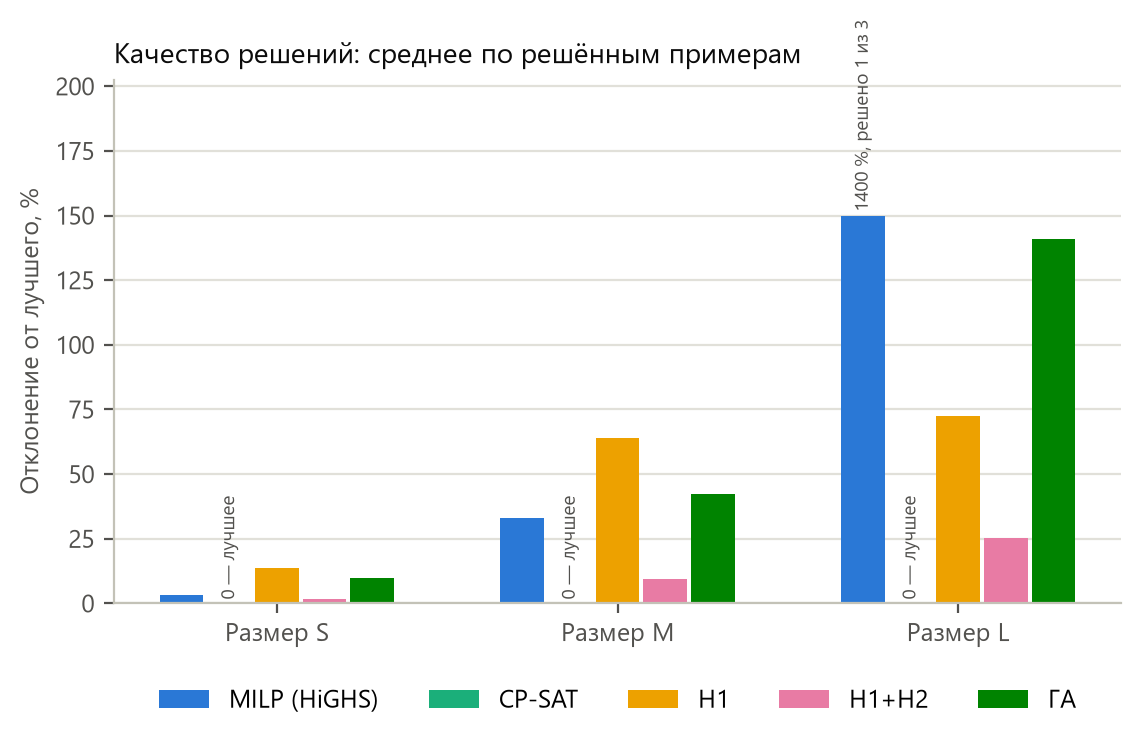

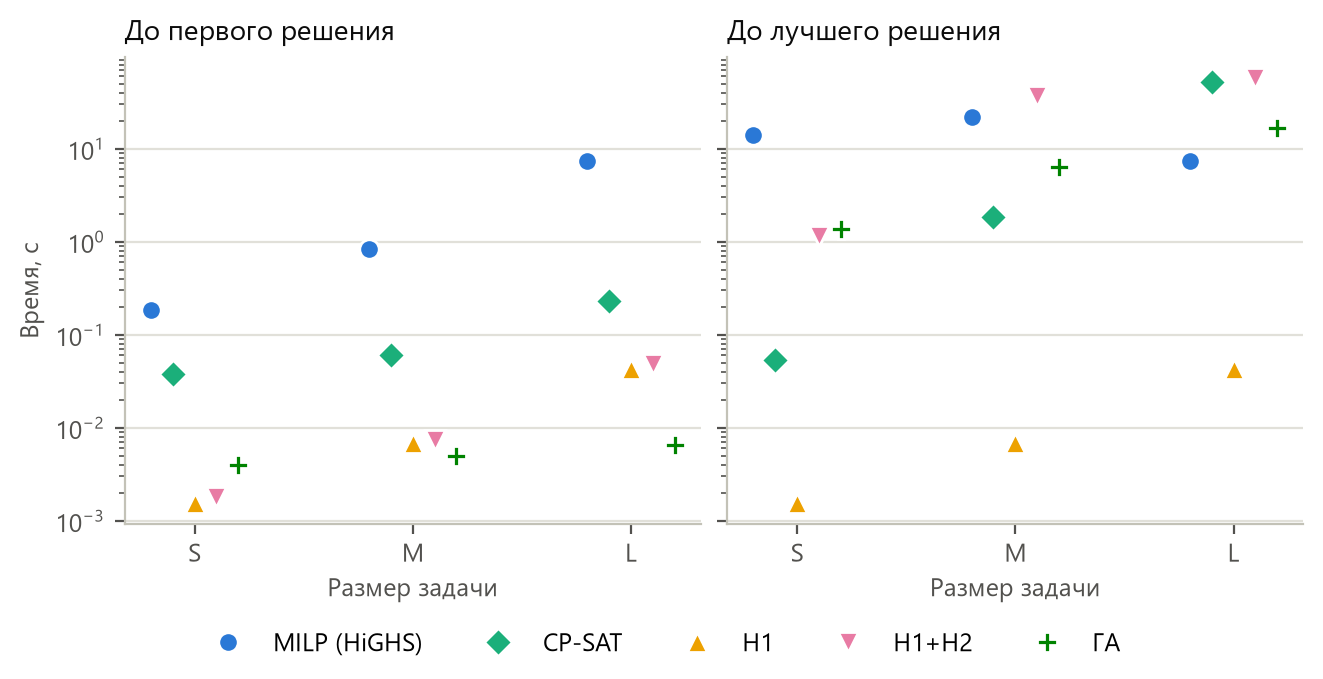

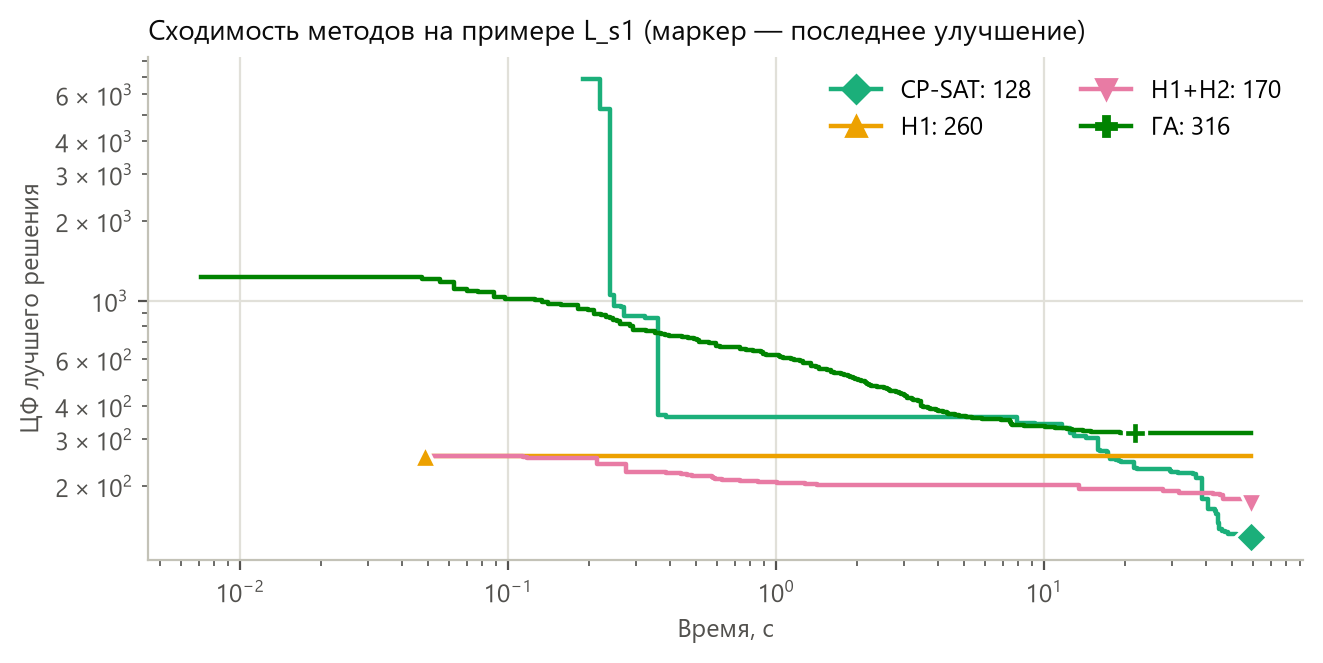

In [13]:
for name in ["comparison_gap.png", "comparison_time.png", "convergence_L_s1.png"]:
    display(Image(f"figures/{name}"))

### Анализ чувствительности (примеры M, лимит 20 с)

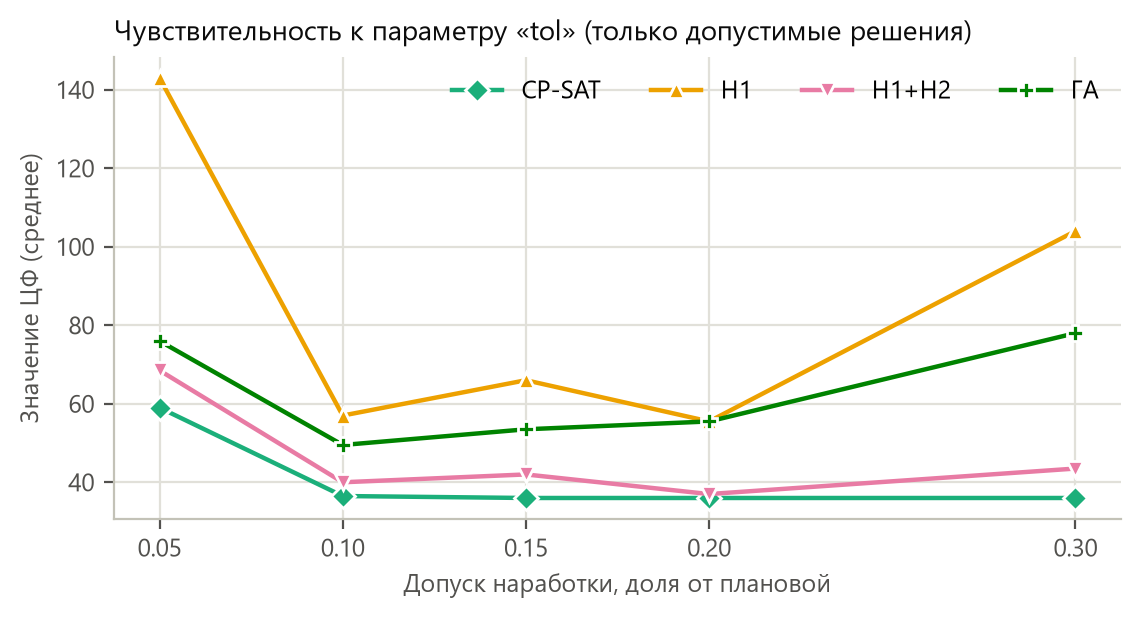

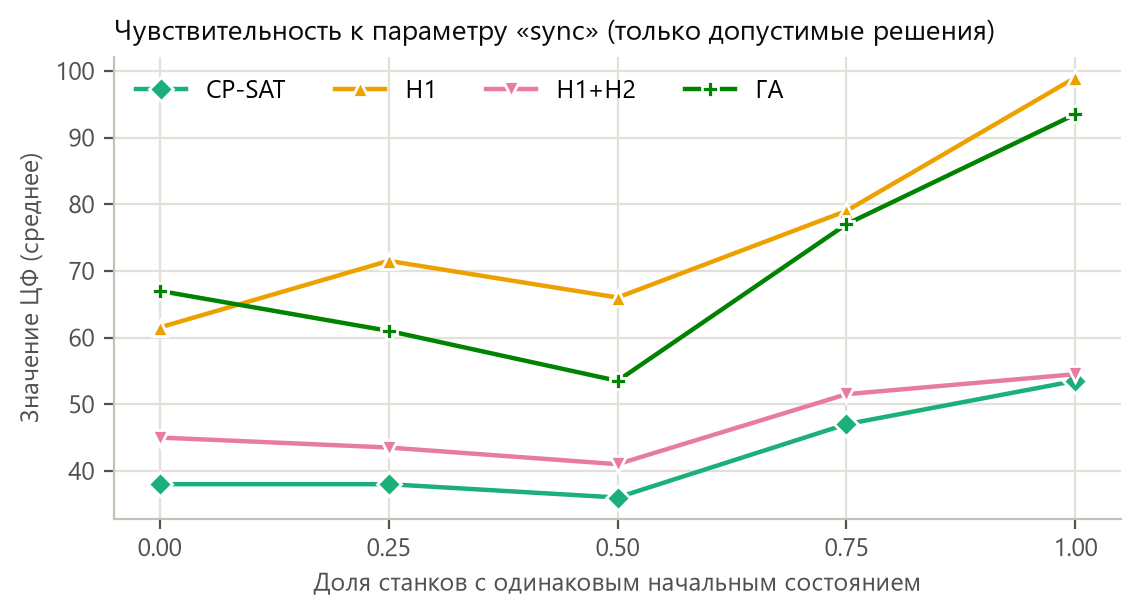

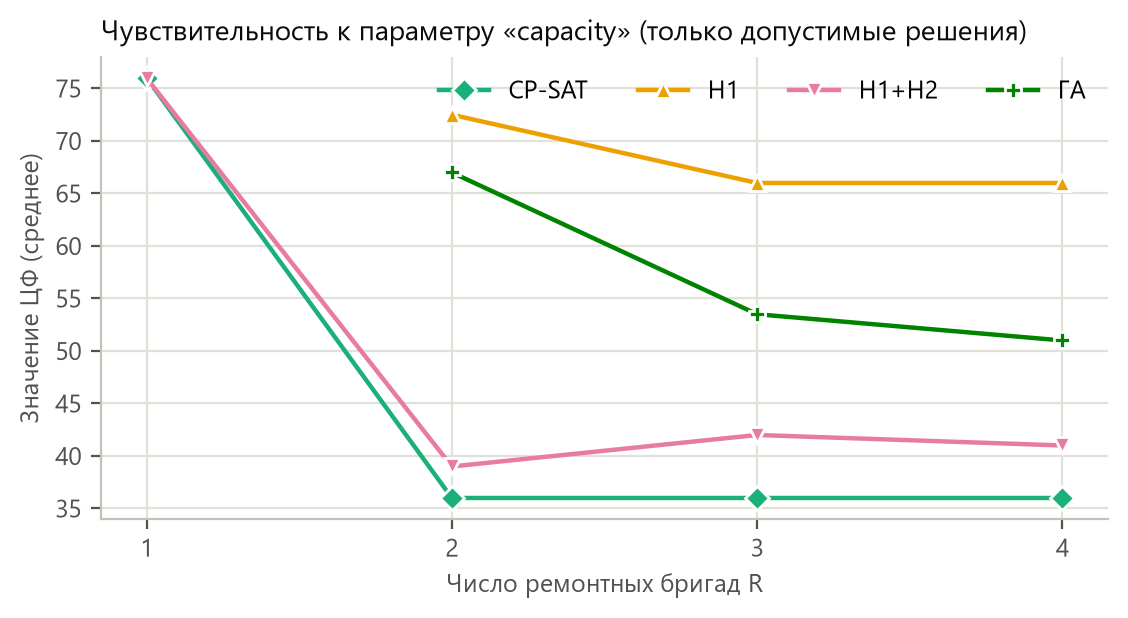

In [14]:
for name in ["sens_tol.png", "sens_sync.png", "sens_capacity.png"]:
    display(Image(f"figures/{name}"))